# Training — P1 baselines + Pipeline A on the local logs

Multi-frame training over the converted py123d logs (split **by log**: last one held out for validation — frames within a log are correlated, a per-frame split would leak). All implementation lives in the `.py` modules; this notebook only wires them:

| block | module |
|---|---|
| targets + loss + loop | `train.py` (`TargetEncoder`, `CenterPointLoss`, `train_model`) |
| models | `network.py` (`LidarOnlyDetector`, `PipelineA/B/C`) |
| stereo input cache | `data.py` (`precompute_stereo_inputs`) |
| decode + distance-AP | `evaluation.py` (`CenterPointDecoder`, `evaluate_model`) |

## 1. Imports

In [2]:
import matplotlib.pyplot as plt
import torch

import globals as G
import utils
from data import Py123dDataset, precompute_stereo_inputs, stereo_cache_root, StereoSGBMConfig
from evaluation import (CenterPointDecoder, compare_reports, evaluate_model,
                        load_report, print_ap_report, save_report)
from network import (CameraOnlyDetector, LidarOnlyDetector, MonoOnlyDetector,
                     PipelineA, lidar_points,PipelineC,PipelineB)
from train import (TargetEncoder, create_run, set_seed, split_frames,
                   split_patches, train_model, validate)

from network import StereoBEVConfig, MonoBEVConfig

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cuda


## 2. Globals

In [3]:
print("grid:", G.GRID_SIZE, "| x:", G.X_RANGE, "| y:", G.Y_RANGE, "| classes:",
      G.CLASSES)

# --- run configuration -------------------------------------------------
MODEL = "pipeline_c"  # "lidar" | "camera" stereo-splat | "mono" pred-depth | "pipeline_a" fused | "pipeline_b" fused | "pipeline_c"
EPOCHS = 50  # upper bound; early stop (below) usually ends the run sooner
LR = 1e-3
ACCUM = 4  # frames per optimizer step (batch-1 + accumulation)

# early stopping: stop once val loss hasn't improved by > MIN_DELTA for
# PATIENCE consecutive epochs (best-val checkpoint is still whatever the
# lowest val loss was — see train.py train_model). None disables it.
PATIENCE = 5
MIN_DELTA = 1e-4

# regularization (Phase 1 — attack overfitting). Both default OFF so a run
# with them at 0 reproduces the current baseline; dial up and A/B in §9.
WEIGHT_DECAY = 1e-4  # AdamW decoupled L2 (try 1e-4..1e-2); 0 = plain Adam
HEAD_DROPOUT = 0.2  # Dropout2d p in the CenterPoint head (try 0.1..0.3)
VAL_SCENES = 1  # FALLBACK ONLY: used when kitti360_val isn't downloaded yet but
# kitti360_train has >1 log (holds out the last n). Ignored once the named
# kitti360_val split exists. int, or explicit log indices to hold out.
SEED = 0  # python/numpy/torch/CUDA RNGs (weight init, shuffling)

# train/val split strategy:
#   "auto"  — named kitti360_val if present, else hold out whole logs,
#             else a (leaky) frame split. Zero leakage only when a
#             separate val drive exists.
#   "patch" — contiguous-patch split of the TRAINING drives: balanced
#             across drives, minimal leakage (only patch boundaries
#             straddle the split, and PATCH_GAP buffers even those).
#             Reserve drive 0010 (kitti360_val) as the untouched TEST
#             set — never patched. Use when 0010 isn't ready yet or you
#             want every drive represented in val.
SPLIT_MODE = "patch"  # "auto" | "patch"
PATCH_LEN = 100  # frames per contiguous patch (~10 s at 10 Hz)
PATCH_VAL_FRAC = 0.2  # fraction of patches held out to val
PATCH_GAP = 5  # frames dropped either side of a train/val boundary

# camera stem (camera / pipeline_a only): "efficientnet" trains a ~1M-param CNN
# from scratch (weak); "yolo26" uses a COCO-pretrained backbone. FREEZE keeps it
# fixed so only the head/BEV/context train — the strong first baseline to try.
CAMERA_BACKBONE = "yolo26"  # "efficientnet" | "yolo26"
FREEZE_BACKBONE = True
# YOLO multi-scale tap (yolo26 only): concat extra neck levels into the
# splatted image features. "p3" (stride 8, finest) = current; "p3p4" /
# "p3p4p5" add coarser large-context levels (upsampled to P3). Wider proj,
# more params. Ignored by the efficientnet stem.
YOLO_LEVELS = "p3p4"  # "p3" | "p3p4" | "p3p4p5"

# depth -> context head (stereo camera only): feed the grounded metric depth
# + a validity mask into the context features before the splat, so the
# splatted features are geometry-aware ("features see the depth"). Splat
# output width is unchanged. False = current baseline.
USE_DEPTH_CONTEXT = False

# Pipeline C cross-attention: True = Gaussian kernel (UniCorrn Eq. 5), False = dot-product
USE_GAUSSIAN_ATTN: bool = True

# stereo depth source (camera / pipeline_a only): "sgbm" sparse ~55%; "igev"
# learned, dense ~100% (needs third_party/IGEV-Stereo + timm); "sgbm_wls"
# rejected. See docs/depth_study_and_baselines.md.
MATCHER = "igev"  # "sgbm" | "igev" | "sgbm_wls"

# decoder NMS: greedy within-class metric radius (m) that removes duplicate
# peaks on large objects (a car holds several the 3x3 max-pool misses). Keyed
# by class index of G.CLASSES; VEHICLE needs the largest radius. Set {} (or all
# zeros) to disable -> the baseline for the with/without-NMS A/B comparison.
NMS_RADIUS_BY_CLASS = {0: 3.0, 1: 0.5, 2: 1.0, 3: 0.5}
# VEHICLE / PERSON / TWO_WHEELER / TRAFFIC_SIGN

# each training run auto-saves to runs/<name>_<timestamp>/ (weights, metrics.csv,
# results.json, plots, config.json). This dict is snapshotted into config.json.
RUN_NAME = (
    MODEL if MODEL == "lidar" else
    f"{MODEL}_{CAMERA_BACKBONE}" if MODEL == "mono"  # no matcher
    else f"{MODEL}_{CAMERA_BACKBONE}_{MATCHER}")
config = dict(name=RUN_NAME,
              model=MODEL,
              camera_backbone=CAMERA_BACKBONE,
              freeze_backbone=FREEZE_BACKBONE,
              matcher=MATCHER,
              epochs=EPOCHS,
              patience=PATIENCE,
              min_delta=MIN_DELTA,
              lr=LR,
              accum=ACCUM,
              seed=SEED,
              classes=list(G.CLASSES),
              nms_radius_by_class=NMS_RADIUS_BY_CLASS,
              split_mode=SPLIT_MODE,
              patch_len=PATCH_LEN,
              patch_val_frac=PATCH_VAL_FRAC,
              patch_gap=PATCH_GAP,
              weight_decay=WEIGHT_DECAY,
              head_dropout=HEAD_DROPOUT,
              yolo_levels=YOLO_LEVELS,
              use_depth_context=USE_DEPTH_CONTEXT,
              use_gaussian_attn=USE_GAUSSIAN_ATTN)

set_seed(SEED)  # reproducible runs (not bit-deterministic: CUDA atomics)

grid: (200, 160) | x: (0.0, 50.0) | y: (-20.0, 20.0) | classes: ('VEHICLE', 'PERSON', 'TWO_WHEELER', 'TRAFFIC_SIGN')


## 3. Data — frame lists, split by log

In [4]:
# KITTI-360 splits are baked in at convert time (scripts/get_kitti360.sh:
# TRAIN_SEQ -> kitti360_train, VAL_SEQ -> kitti360_val). Pipeline A trains on
# drives 0003+0007+0009, validates on the held-out 0010 (converted via
# TRAIN_SEQ="0003 0007 0009" VAL_SEQ="0010" scripts/get_kitti360.sh).
# Degrades gracefully if that isn't the on-disk state yet:
#   1. kitti360_val present            -> proper scene-level held-out log
#   2. no val split but >1 train scene -> hold out VAL_SCENES logs (§2)
#   3. only one scene (smoke test)     -> TEMPORARY frame-level split
dataset = Py123dDataset(split_names=["kitti360_train"])
try:
    val_dataset = Py123dDataset(split_names=["kitti360_val"])
    has_val_split = val_dataset.scene_count > 0
except Exception:
    val_dataset, has_val_split = None, False

_all = lambda ds: [
    f for s in range(ds.scene_count) for f in ds.frames_in_scene(s)
]

if SPLIT_MODE == "patch":
    train_frames, val_frames = split_patches(dataset,
                                             val_frac=PATCH_VAL_FRAC,
                                             patch_len=PATCH_LEN,
                                             seed=SEED,
                                             gap=PATCH_GAP)
    frac = len(val_frames) / max(1, len(train_frames) + len(val_frames))
    print(f"patch split | train: {len(train_frames)} | val: {len(val_frames)}"
          f" frames from {dataset.scene_count} drive(s) "
          f"(patch_len={PATCH_LEN}, gap={PATCH_GAP}, val≈{frac:.0%})")
    if has_val_split:
        print(f"  note: kitti360_val ({val_dataset.scene_count} log) reserved "
              f"as untouched TEST — evaluate on it separately (§8).")
elif has_val_split:
    train_frames, val_frames = _all(dataset), _all(val_dataset)
    print(f"named splits | train: {len(train_frames)} frames "
          f"({dataset.scene_count} logs) | val: {len(val_frames)} frames "
          f"({val_dataset.scene_count} logs)")
    # Pipeline A split contract: train = drives 03/07/09, val = drive 10.
    # Fails loud (not silently trains on the wrong drives) if the on-disk
    # kitti360_train/kitti360_val content ever drifts from that.
    train_logs = sorted({f.log_name for f in train_frames})
    val_logs = sorted({f.log_name for f in val_frames})
    print(f"  train drives: {train_logs}\n  val drives:   {val_logs}")
    EXPECTED_TRAIN_DRIVES = {"2013_05_28_drive_0003_sync",
                             "2013_05_28_drive_0007_sync",
                             "2013_05_28_drive_0009_sync"}
    EXPECTED_VAL_DRIVES = {"2013_05_28_drive_0010_sync"}
    assert set(train_logs) == EXPECTED_TRAIN_DRIVES, (
        f"expected train drives {sorted(EXPECTED_TRAIN_DRIVES)}, got {train_logs} "
        "— re-run scripts/get_kitti360.sh with TRAIN_SEQ=\"0003 0007 0009\"")
    assert set(val_logs) == EXPECTED_VAL_DRIVES, (
        f"expected val drives {sorted(EXPECTED_VAL_DRIVES)}, got {val_logs} "
        "— re-run scripts/get_kitti360.sh with VAL_SEQ=\"0010\"")
elif dataset.scene_count > 1:
    train_frames, val_frames = split_frames(dataset, val_scenes=VAL_SCENES)
    print(f"scene split | train: {len(train_frames)} frames "
          f"({dataset.scene_count - VAL_SCENES} logs) | "
          f"val: {len(val_frames)} frames ({VAL_SCENES} log)")
else:
    # Single scene only — download not finished. Consecutive frames of one drive
    # are strongly correlated, so this LEAKS train into val: a plumbing smoke
    # test ONLY, not a valid AP. Replace once kitti360_val exists (§Next).
    frames = list(dataset.frames_in_scene(0))
    cut = int(0.8 * len(frames))
    train_frames, val_frames = frames[:cut], frames[cut:]
    print(
        f"⚠ TEMPORARY frame-level split of 1 scene — NOT a valid eval "
        f"(train/val correlated).\n  {dataset}\n"
        f"  train: {len(train_frames)} frames | val: {len(val_frames)} frames")

DEBUG: PY123D_DATA_ROOT resolved to /home/vittorio/datasets/av2
DEBUG: found 3 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_train'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_duration_s=None, future_duration_s=None, history_duration_s=None, timestamp_threshold_s=None, target_iteration_stride=None, future_num_iterations=None, history_num_iterations=None, iteration_threshold=None, required_scene_modalities=None, custom_filter_fns=None, num_chunks=None, chunk_idx=None, max_num_scenes=None, shuffle=False)
DEBUG: PY123D_DATA_ROOT resolved to /home/vittorio/datasets/av2
DEBUG: found 1 scenes using filter SceneFilter(datasets=None, split_types=None, split_names=['kitti360_val'], log_names=None, has_map=None, map_has_z=None, map_locations=None, map_version=None, log_locations=None, log_version=None, scene_uuids=None, target_iteration_dura

## 4. Stereo input cache (one-time, camera training only)

SGBM is ~1–2 s/frame on CPU and never changes, so precompute the camera-branch inputs once (<1 MB/frame, resumable — already-cached frames are skipped). Not needed for the LiDAR-only baseline; expect ~15–25 min for all 784 frames on first run.

In [5]:
# learned matchers (e.g. "igev") live in an optional registry — register before
# use. SGBM needs nothing. IGEV needs third_party/IGEV-Stereo + igev_kitti15.pth.
# if MODEL not in ("lidar", "mono") and MATCHER != "sgbm":
#     import igev_matcher
#     igev_matcher.register()

# matcher-aware cache: igev -> preprocessed/stereo_inputs_igev (coexists w/ sgbm)
CACHE_ROOT = stereo_cache_root(dataset.data_root, matcher=MATCHER)
if MODEL not in ("lidar", "mono"):  # mono predicts depth, no cache
    # cover val too — in the named-split case it's a separate dataset, else eval
    # falls back to slow live matching. Resumable: cached frames are skipped.
    # IGEV is GPU (~0.5 s/frame) on first build, then free at train time.
    precompute_stereo_inputs(train_frames + val_frames,
                             CACHE_ROOT,
                             sgbm_cfg=StereoSGBMConfig(matcher=MATCHER))
if MODEL == "mono":
    print("mono (predicted depth) — no stereo cache needed")
else:
    print(f"cache root ({MATCHER}):", CACHE_ROOT)

stereo input cache: 0 written, 16577 already cached → /home/vittorio/datasets/av2/preprocessed/stereo_inputs_igev
cache root (igev): /home/vittorio/datasets/av2/preprocessed/stereo_inputs_igev


## 5. Network

In [6]:
# camera-branch config: pick the backbone + freeze from §2 (ignored by lidar).
stereo_cfg = StereoBEVConfig(img_backbone=CAMERA_BACKBONE,
                             yolo_freeze=FREEZE_BACKBONE,
                             yolo_levels=YOLO_LEVELS,
                             use_depth_context=USE_DEPTH_CONTEXT)

if MODEL == "lidar":
    model = LidarOnlyDetector(head_dropout=HEAD_DROPOUT)
    input_fn = lidar_points  # sample -> (N, 4) points
elif MODEL == "camera":
    model = CameraOnlyDetector(stereo_cache_root=CACHE_ROOT,
                               stereo_cfg=stereo_cfg,
                               head_dropout=HEAD_DROPOUT)
    input_fn = None  # consumes the sample itself
elif MODEL == "mono":
    mono_cfg = MonoBEVConfig(img_backbone=CAMERA_BACKBONE,
                             yolo_freeze=FREEZE_BACKBONE,
                             yolo_levels=YOLO_LEVELS)
    model = MonoOnlyDetector(mono_cfg=mono_cfg, head_dropout=HEAD_DROPOUT)
    input_fn = None  # predicts its own depth — no stereo cache
elif MODEL == "pipeline_b":
    model = PipelineB(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg)
    input_fn = None
elif MODEL == "pipeline_c":
    model = PipelineC(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg,
                      use_gaussian_attn=USE_GAUSSIAN_ATTN)
    input_fn = None
else:
    model = PipelineA(stereo_cache_root=CACHE_ROOT, stereo_cfg=stereo_cfg)
    input_fn = None

# mono has no stereo cache, so it needs the live left image; the stereo/lidar
# paths keep the fast no-image assembly (they read the cache / only need points).
SAMPLE_KWARGS = {
    "load_images": True,
    "point_mask": False
} if MODEL == "mono" else None

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f"{type(model).__name__}: {trainable:,} trainable" +
      (f" | {frozen:,} frozen ({CAMERA_BACKBONE} backbone)" if frozen else ""))

PipelineC: 1,411,147 trainable | 2,572,280 frozen (yolo26 backbone)


## 6. Train

In [ ]:
# creates runs/<name>_<timestamp>/ and auto-saves best.pt/last.pt, metrics.csv
# (per-epoch loss + P/R/F1/mAP) and loss_curves.png. Prints P/R/F1/mAP each val.
# Early stop (PATIENCE/MIN_DELTA, §2) can end the run before EPOCHS is reached.
RUN_DIR = create_run(config)
history = train_model(model,
                      train_frames,
                      val_frames,
                      input_fn=input_fn,
                      epochs=EPOCHS,
                      lr=LR,
                      accum=ACCUMa,
                      weight_decay=WEIGHT_DECAY,
                      nms_radius_by_class=NMS_RADIUS_BY_CLASS,
                      run_dir=RUN_DIR,
                      sample_kwargs=SAMPLE_KWARGS,
                      patience=PATIENCE,
                      min_delta=MIN_DELTA,
                      device=DEVICE)

run dir: runs/pipeline_c_yolo26_igev_20260708_103240


/home/vittorio/Desktop/AIRO/CV/stereo-lidar-perception/train.py:199: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total, {"heatmap": float(hm_loss), "offset": float(off_loss)}


  epoch 1 step 50/13452 loss 113.205
  epoch 1 step 100/13452 loss 15.491
  epoch 1 step 150/13452 loss 9.691
  epoch 1 step 200/13452 loss 27.567
  epoch 1 step 250/13452 loss 6.567
  epoch 1 step 300/13452 loss 6.851
  epoch 1 step 350/13452 loss 4.956
  epoch 1 step 400/13452 loss 8.135
  epoch 1 step 450/13452 loss 4.342
  epoch 1 step 500/13452 loss 3.639
  epoch 1 step 550/13452 loss 4.647
  epoch 1 step 600/13452 loss 4.661
  epoch 1 step 650/13452 loss 4.779
  epoch 1 step 700/13452 loss 3.309
  epoch 1 step 750/13452 loss 4.464
  epoch 1 step 800/13452 loss 3.028
  epoch 1 step 850/13452 loss 5.016
  epoch 1 step 900/13452 loss 3.467
  epoch 1 step 950/13452 loss 3.649
  epoch 1 step 1000/13452 loss 2.953
  epoch 1 step 1050/13452 loss 5.388
  epoch 1 step 1100/13452 loss 3.449
  epoch 1 step 1150/13452 loss 4.319
  epoch 1 step 1200/13452 loss 2.363
  epoch 1 step 1250/13452 loss 2.272
  epoch 1 step 1300/13452 loss 1.185
  epoch 1 step 1350/13452 loss 3.386
  epoch 1 step 14

KeyboardInterrupt: 

NameError: name 'history' is not defined

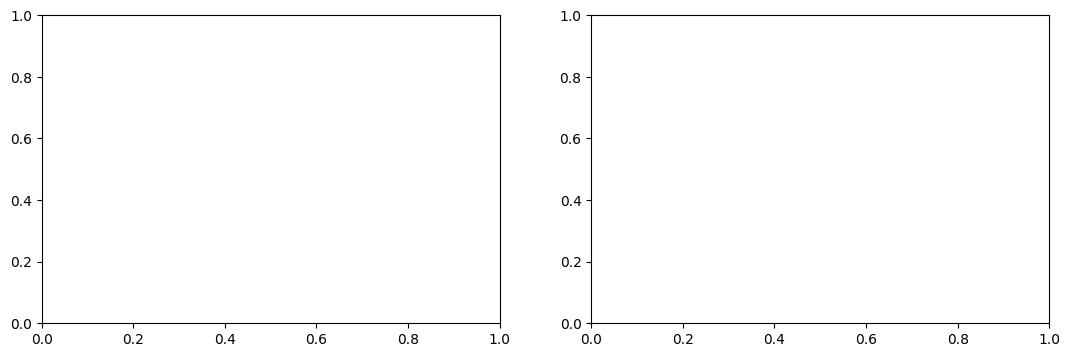

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(history["steps"], alpha=0.6)
ax[0].set_yscale("log")
ax[0].set_title("per-step loss")
ax[0].set_xlabel("step")
ax[1].plot(history["train"], "o-", label="train")
ax[1].plot(history["val"], "s-", label="val")
ax[1].set_title("per-epoch mean loss")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.show()

## 7. Test — distance-AP on the held-out log

Center-distance (AV2-style bands): a detection is a TP if its centre lands within 0.5/1/2/4 m of an unmatched GT centre of the same class. Loads the best-val checkpoint first.

In [ ]:
# load the best-val checkpoint from the run dir, then score with the chosen NMS.
from pathlib import Path

CKPT = Path(RUN_DIR) / "weights" / "best.pt"
utils.load_state_dict_compat(model,
                             torch.load(CKPT, weights_only=True)["model"])
report = evaluate_model(model,
                        val_frames,
                        input_fn=input_fn,
                        device=DEVICE,
                        nms_radius_by_class=NMS_RADIUS_BY_CLASS,
                        sample_kwargs=SAMPLE_KWARGS)
print_ap_report(report)
# results.json + plots/evaluation.png + summary.txt into the run dir
utils.save_eval_artifacts(RUN_DIR, report)

In [ ]:
# PR curves + F1-vs-confidence (read the deployment threshold off the peak)
# + confusion matrix (background row = FP, background column = missed GT)
utils.visualize_evaluation(report)

In [ ]:
# qualitative check: decoded detections vs GT on a few val frames
model.eval()
# same NMS as the eval/metrics — otherwise the picture shows the raw,
# un-suppressed peaks (duplicate detections on one car) and looks broken.
decoder = CenterPointDecoder(score_threshold=0.2,
                             nms_radius_by_class=NMS_RADIUS_BY_CLASS)
for frame in val_frames[20:151:70]:
    sample = frame.to_stereo_sample()
    with torch.no_grad():
        out = model(input_fn(sample) if input_fn else sample, device=DEVICE)
    det = decoder(out["heatmap"].cpu(), out["offset"].cpu())[0]
    utils.visualize_detections(sample, det)

In [ ]:
# stereo -> BEV diagnostic: does the net SEE objects (panel 1) but fail to PLACE
# them in BEV because the stereo depth is missing/wrong (panel 3) -> empty output
# (panel 4)? Needs full samples (images). Camera / pipeline_a only.
if MODEL != "lidar":
    # Keep the first example aligned with the one previously used, then vary the
    # second and third frames to show different cases.
    example_frames = [
        val_frames[10], val_frames[490], val_frames[495], val_frames[712],
        val_frames[485], val_frames[120]
    ]
    for frame in example_frames:
        sample = frame.to_stereo_sample()  # full sample (load_images=True)
        utils.visualize_stereo_bev_diagnostic(
            model,
            sample,
            device=DEVICE,
            score_threshold=0.15,
            nms_radius_by_class=NMS_RADIUS_BY_CLASS)
else:
    print("stereo diagnostic is camera/fusion only (needs the stereo branch)")

## 8. Branch contribution (fused runs only)

Two complementary measurements:

1. **Baselines table** — train `lidar`, `camera`, `pipeline_a` with this same notebook (same split/seed/epochs) and compare their AP tables. Fusion's contribution = `pipeline_a` − best single-sensor baseline.
2. **Branch dropout** — evaluate the *trained* fused model with one branch zeroed (`drop_branch`): the AP drop is that branch's marginal contribution inside the fusion. Caveat: a zeroed map is a "silent sensor" the fusion conv never saw in training — it bounds the contribution, it's not a retrained baseline.

In [ ]:
if MODEL == "pipeline_a":
    for drop in (None, "camera", "lidar"):
        model.drop_branch = drop
        rep = evaluate_model(model,
                             val_frames,
                             input_fn=input_fn,
                             device=DEVICE)
        print(f"\n=== drop_branch = {drop} "
              f"(mAP {rep['mAP']:.3f}) {'=' * 30}")
        print_ap_report(rep)
    model.drop_branch = None  # always reset
else:
    print(
        "single-sensor run — train MODEL='pipeline_a' for the dropout ablation"
    )

## 9. Compare saved approaches

Every §7 run wrote `results/<MODEL>.json`. Load them all back and print one
table — no re-evaluation needed. Run this after you've trained + tested each of
`lidar`, `camera`, `pipeline_a` (same split/seed). The per-class columns are the
mean AP over the 0.5/1/2/4 m thresholds; P/R/F1 are macro at the 2 m operating
point. Fusion's contribution = `pipeline_a` row − best single-sensor row.

In [ ]:
from pathlib import Path

# every run wrote runs/<name>/results.json — load them all into one table
# (no re-evaluation). Compare per-class AP, not just mAP (sparse classes skew it).
runs = {
    p.parent.name: load_report(p)
    for p in sorted(Path("runs").glob("*/results.json"))
}
if runs:
    compare_reports(runs)
else:
    print("no runs yet — train + eval a MODEL first")

## Next

- Run all three: `MODEL = "lidar"` → `"camera"` → `"pipeline_a"` (same split/seed) and build the baselines-vs-fusion AP table; then the §8 dropout ablation on the fused checkpoint.
- More data: download more KITTI-360 sequences via `scripts/get_kitti360.sh` (e.g. `TRAIN_SEQ="0000 0002 0004"`); urban drives add PERSON/TWO_WHEELER support. Keep drive_0010 (`kitti360_val`) purely for eval.
- BEV augmentation (rotation/flip), warm-start the fused run from the baselines, per-range AP bins, and the full CDS metric.